<a href="https://colab.research.google.com/github/narmadhabalaji/Seoul-Bike-Sharing-Demand-Analysis/blob/main/Seoul_Bike_Sharing_Demand_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Seoul Bike Sharing Demand Analysis**
Problem Definition:
  * The demand for bike sharing in Seoul varies based on factors such as weather conditions, seasons, holidays and time-related factors.
  * However, it is not clearly understood which of these factors affect bike rentals the most and how they impact usage patterns.
  * This analysis aims to identify the key factors affecting bike rental demand and discover meaningful patterns and insights from the data.

##**Domain**
Transportation

# **Objectives**

1. To study the impact of weather factors like temperature, rainfall and snowfall on bike demand.

2. To analyze rental bike usage pattern in Seoul city across different seasons, holidays and working days.

3. To perform different types of analysis (univariate,bivariate, etc) to identify key patterns.

4. To derive clear actionable insights for better planning and resource optimization.

# **Business Problem**

Bike sharing system is one of an important part of urban transportation in Seoul.
In order to support better planning and resource management it is important to understand how weather,seasonal and time-related factors affect the rental bike demand.

# **Outcome**
* This project helps understand how different factors like weather, seasons and holidays affect bike rentals in Seoul.
* The analysis shows when people use bikes more, when demand is low and what conditions influences usage.
* These insights can help city planners and service providers manage bikes better, improve availability and support smarter transportation planning.

#**Dataset Information**

**Source:** UCI ML - https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

**Year / Timeline:** 2017 - 2018

**Dataset Column Description:**

* **Date**- Bike rented date(dd-mm-yyyy)

* **Rented Bike Count** - Count of bikes rented at each hour

* **Hour** - Hour of the day (0–23) at which bike rental count is recorded.

* **Temperature** - Temperature of the day (°C).

* **Humidity** - The percentage of humidity in the air (%).

* **Windspeed** - Speed of wind in m/s

* **Visibility** - The visibility distance measured in units of 10 meters.

* **Dew point temperature** - The temperature at which dew forms (°C).

* **Solar radiation** - Amount of solar energy received per square meter (MJ/m²).

* **Rainfall** - The amount of rainfall recorded in millimeters (mm).

* **Snowfall** - The amount of snowfall recorded in centimeters (cm).

* **Seasons** - The season during the record (Winter, Spring, Summer, Autumn).

* **Holiday** - Indicates whether the day is a holiday or not (Holiday / No Holiday).

* **Functional Day** - Indicates whether the bike sharing system was operating normally on that day.


# **Note For Kind of Analysis to be done**

**Type of Analysis**

* Descriptive Analysis (summarizing the dataset)

* Diagnostic Analysis (finding reasons behind patterns)

* Predictive Analysis (optional if forecasting required using basic stats)

* Prescriptive Analysis (recommendations for business decisions)

# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection

Define the business problem and expected outcome

Choose dataset and explain its source, size and features

Import libraries, load dataset

Dataset description (rows, columns, features)

Initial EDA (head, info, describe, shape, null checks, duplicate check)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=("https://raw.githubusercontent.com/narmadhabalaji/Seoul-Bike-Sharing-Demand-Analysis/main/SeoulBikeData.csv")


In [ ]:
df=pd.read_csv(data,encoding='latin1')
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


The dataset had some special characters, so the default UTF-8 encoding caused issues.
Using latin1 helped load the data smoothly without errors.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [ ]:
df.shape

(8760, 14)

In [ ]:
df.describe().round(2)

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00
mean,704.60,11.50,12.88,58.23,1.72,1436.83,4.07,0.57,0.15,0.08
std,645.00,6.92,11.94,20.36,1.04,608.30,13.06,0.87,1.13,0.44
min,0.00,0.00,-17.80,0.00,0.00,27.00,-30.60,0.00,0.00,0.00
25%,191.00,5.75,3.50,42.00,0.90,940.00,-4.70,0.00,0.00,0.00
50%,504.50,11.50,13.70,57.00,1.50,1698.00,5.10,0.01,0.00,0.00
75%,1065.25,17.25,22.50,74.00,2.30,2000.00,14.80,0.93,0.00,0.00
max,3556.00,23.00,39.40,98.00,7.40,2000.00,27.20,3.52,35.00,8.80


In [ ]:
df.describe(include=object)

,Date,Seasons,Holiday,Functioning Day
count,8760,8760,8760,8760
unique,365,4,2,2
top,30/11/2018,Spring,No Holiday,Yes
freq,24,2208,8328,8465


In [ ]:
df.isnull().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [ ]:
df.duplicated().value_counts()

,count
False,8760


Based on the initial exploration, the dataset is clean, well-structured and suitable for further analysis.

## Stage 2 – Data Cleaning and Pre-processing

Handle missing values (impute or drop)

Handle duplicates

Treat outliers if required

Check skewness and apply transformations

Convert data types if needed

Feature transformations (date parts, derived fields if required for analysis)

In [ ]:
df['Date']=pd.to_datetime(df['Date'],dayfirst=True)

In [ ]:
print(df['Date'].dtype)

datetime64[ns]


In [ ]:
num_col=df.select_dtypes(include='number')
num_col

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0
8756,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0
8757,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0
8758,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0


In [ ]:
num_col_skew=num_col.skew()
num_col_skew.round(2)

,0
Rented Bike Count,1.15
Hour,0.00
Temperature(°C),-0.20
Humidity(%),0.06
Wind speed (m/s),0.89
Visibility (10m),-0.70
Dew point temperature(°C),-0.37
Solar Radiation (MJ/m2),1.50
Rainfall(mm),14.53
Snowfall (cm),8.44


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


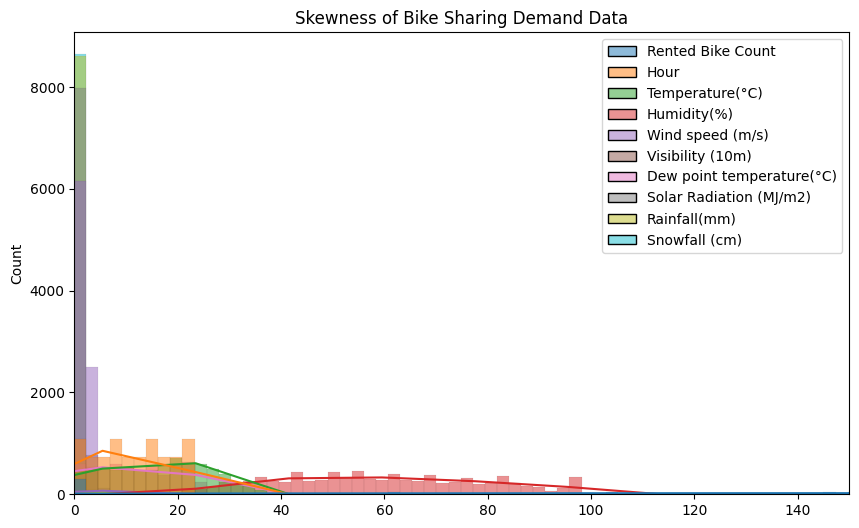

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,kde=True)
plt.title("Skewness of Bike Sharing Demand Data")
plt.xlim(0,150)
plt.show()

* Since there are no null values or duplicate records, no imputation or row removal was required.
* Date was converted to datetime format for time-based analysis.
* Although some numerical features like solar radiation, rainfall and snowfall show high positive skewness, no transformation is applied as the skewness represents the real-world weather behavior and the focus of this project is exploratory analysis and business insights.

## Stage 3 – EDA and Visualizations

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

Interpretation MUST with every visualization

Focus on business story not just charts

Each chart must be in seperate cells.

In [ ]:
green_aurora = "#2E7D32"


### Distribution of Rented Bike Count

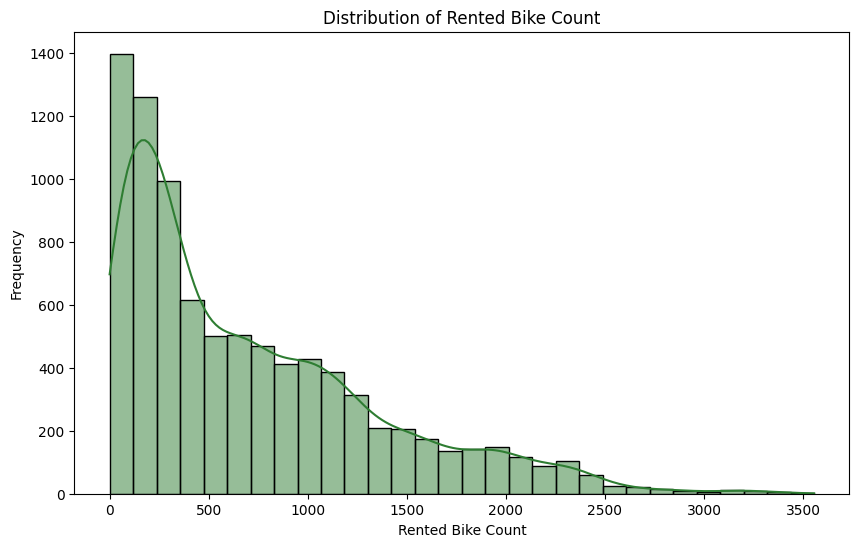

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df['Rented Bike Count'],kde=True,bins=30,color=green_aurora)
plt.title("Distribution of Rented Bike Count")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.show()

* The above chart shows how bike rental counts are distributed across the recorded hours.
* Most rental values fall in the lower to mid range, with a few hours showing very high rental demand.
* Features Used - Rented Bike Count
* Thus the above chart indicated that bike demand is not evenly spread across time and tends to spike at specific hours.

### Average Bike Rentals by Hour

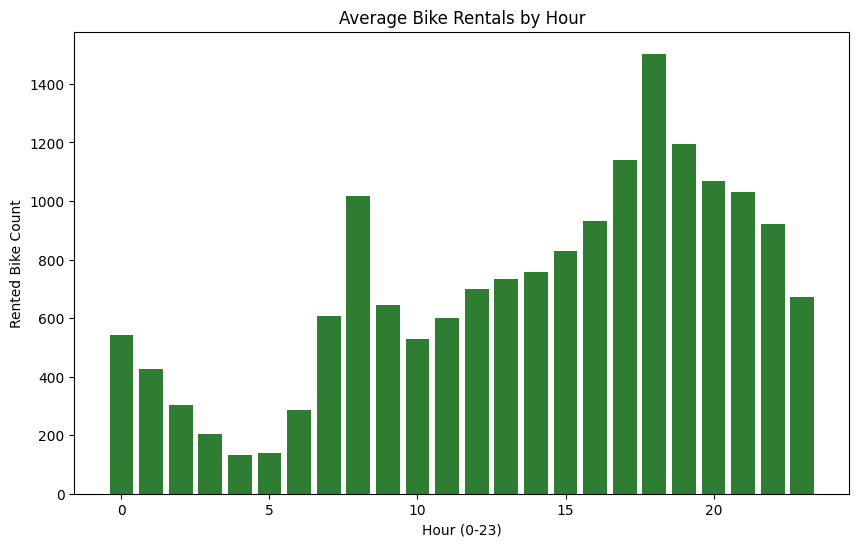

In [ ]:
hr_avg=df.groupby('Hour')['Rented Bike Count'].mean().round(2)

plt.figure(figsize=(10,6))
plt.bar(hr_avg.index,hr_avg.values,color=green_aurora)
plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour (0-23)")
plt.ylabel("Rented Bike Count")
plt.show()


* The above bar chart represents the average number of bike rented at each hour of the day
* Bike rental demand is lower at the late evenings and early mornings and increases significantly during morning and peak evening hours.
* Features Used - Hour, Rented Bike Count
* This shows that there is a strong bike usage pattern in Seoul, with peak demand during office travel hours.

### Boxplot of Rented Bike Count

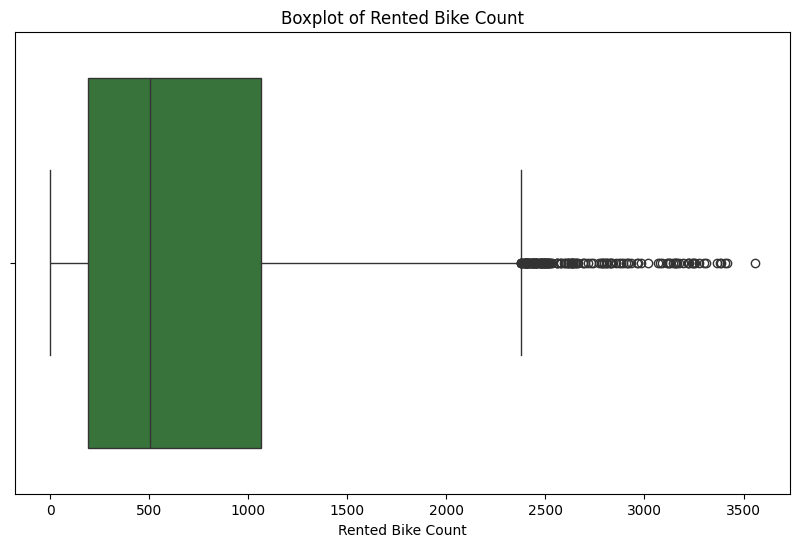

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x=df['Rented Bike Count'],color=green_aurora)
plt.title("Boxplot of Rented Bike Count")
plt.show()

* The above chart shows the distribution of the rental bike count and the presence of outliers.
* While several points are present beyond the upper whisker, most of the values are concentrated within certain range indicates the unusual high rental demand during some hours.
* Features Used - Rented Bike Count
* This indicates that bike demand peaks during specific commute hours, which is important for planning bike availability.

### Monthly Bike Rental Trend

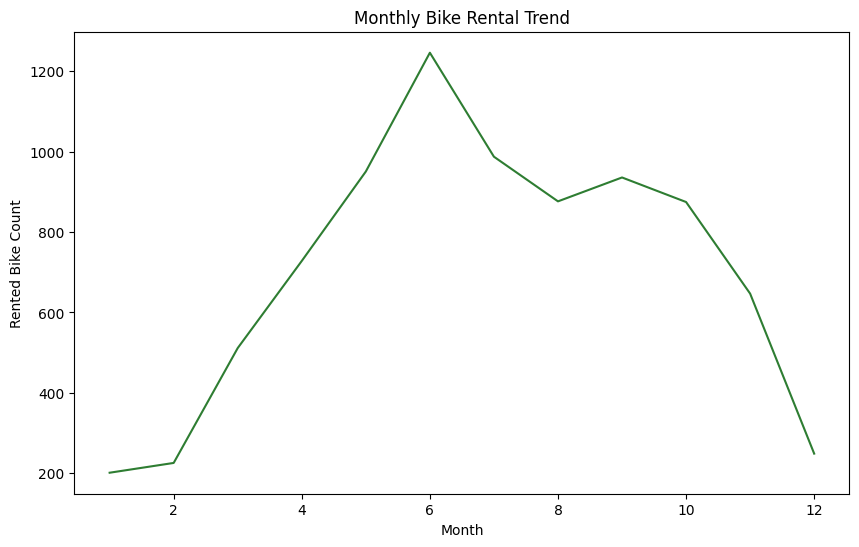

In [ ]:
df['Month']=df['Date'].dt.month

monthly_avg=df.groupby('Month')['Rented Bike Count'].mean().round(2)

plt.figure(figsize=(10,6))
plt.plot(monthly_avg.index,monthly_avg.values,color=green_aurora)
plt.xlabel("Month")
plt.ylabel("Rented Bike Count")
plt.title("Monthly Bike Rental Trend")
plt.show()

* The above line chart indicates the average number of bikes rented across different months in a year.
* Bike rental demand increases during the middle of the year and decreases during the early and later months.
* Features Used - Month, Rented Bike Count
* This suggests that the bike demand peaks during the warmer weather and decline during colder weather.
* Thus seasonal conditions influences the bike rental behavior in Seoul.

# Descriptive Analysis - Key Insights

* Bike rental demand is uneven and shows clear peaks during specific hours of the day.
* Rentals are highest during morning and evening hours and lowest during early mornings and late evenings.
* Monthly trends show higher demand during warmer months and lower demand during colder months.
* Overall bike usage varies significantly across time and seasons in Seoul.


### Temperature vs Rented Bike Count

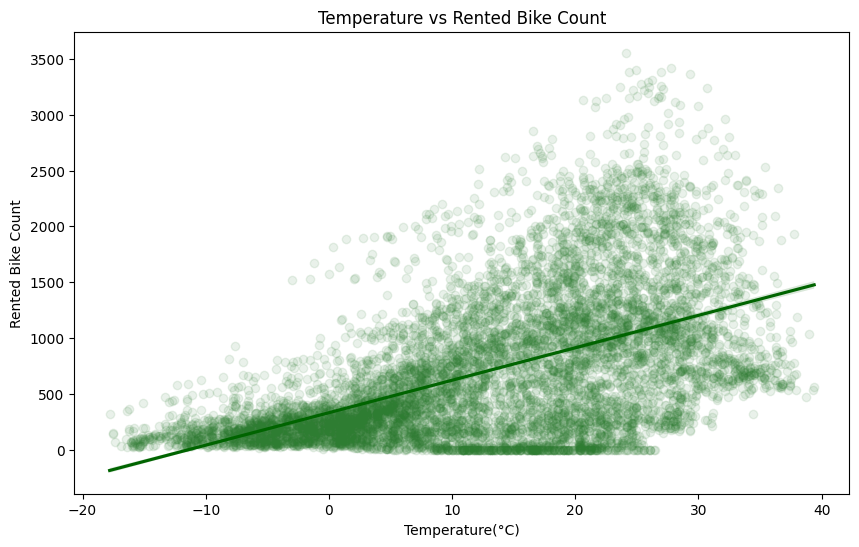

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(data=df,x='Temperature(°C)', y='Rented Bike Count',color=green_aurora,line_kws={'color':'darkgreen'},scatter_kws={'alpha':0.1})
plt.title('Temperature vs Rented Bike Count')
plt.xlabel("Temperature(°C)")
plt.ylabel("Rented Bike Count")
plt.show()

* The regresion plot indicates the relation between the Temperature(°C) and Rented Bike Count.
* The upward sloping indicates positive relation between these two factors.
* Features Used - Temperature(°C), Rented Bike Count
* As the temperature increases the bike rental demand also increases, indicating warmer weather conditions encourage higher bike usage than colder weather conditions.

### Rainfall vs Rented Bike Count

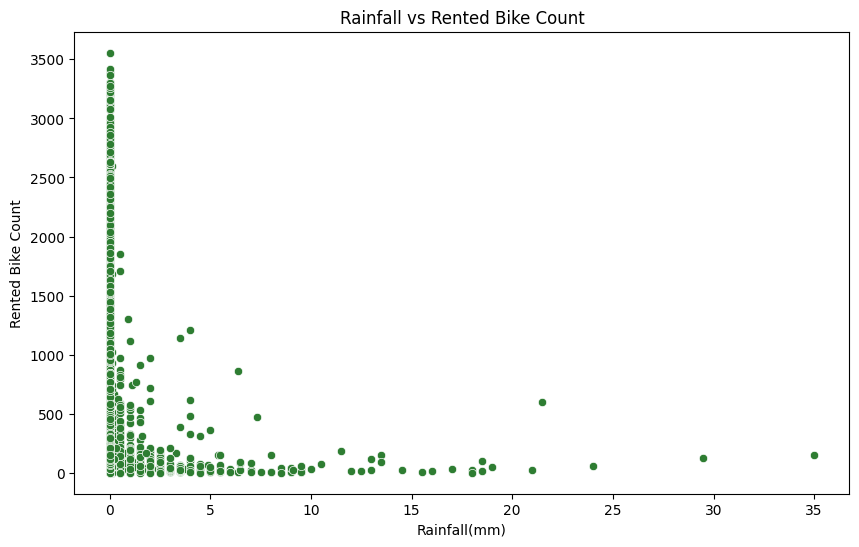

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Rainfall(mm)', y='Rented Bike Count',color=green_aurora)
plt.title('Rainfall vs Rented Bike Count')
plt.xlabel("Rainfall(mm)")
plt.ylabel("Rented Bike Count")
plt.show()

* The above scatter plot indicates the relationship between Rainfall(mm) and Rented Bike Count.
* The bike demand increases when there is no rainfall and significantly decreases during rainy days.
* Features Used - Rainfall(mm), Rented Bike Count
* Rainfall has a strong negative impact on bike rentals, indicating people avoid bike usage during rainy conditions, leading to reduced demand.

### Average Bike Rented by Seasons

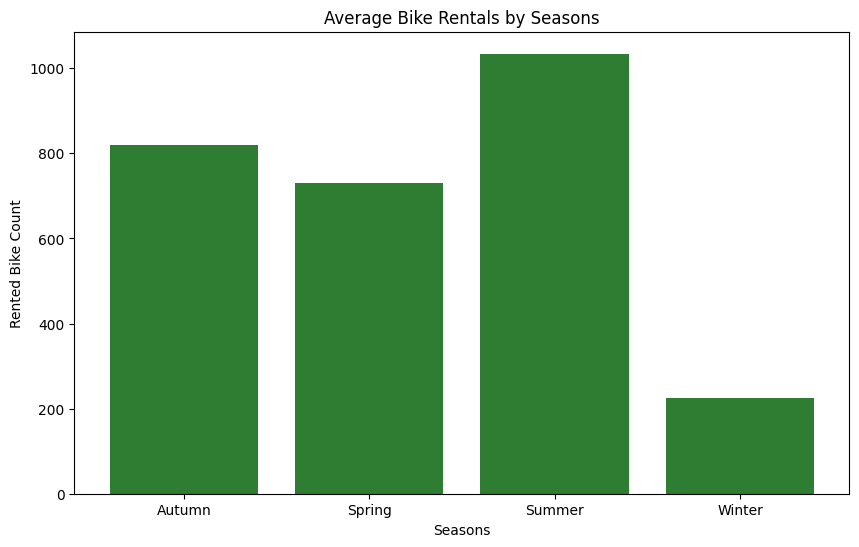

In [ ]:
season_avg=df.groupby('Seasons')['Rented Bike Count'].mean().round(2)

plt.figure(figsize=(10,6))
plt.bar(season_avg.index,season_avg.values,color=green_aurora)
plt.title("Average Bike Rentals by Seasons")
plt.xlabel("Seasons")
plt.ylabel("Rented Bike Count")
plt.show()

* The above bar chart shows the relationship between Seasons and Rented Bike Count.
* Bike rental demand is the highest during Summer, moderate during Autumn and Spring and lowest during Winter.
* Features Used - Seasons, Rented Bike Count
* Seasonal weather conditions strongly influencess the rental bike usage. Warmer weather conditions encourage travel whereas colder conditions reduce bike demand.

### Bike Rental Distribution: Holiday vs Non-Holiday

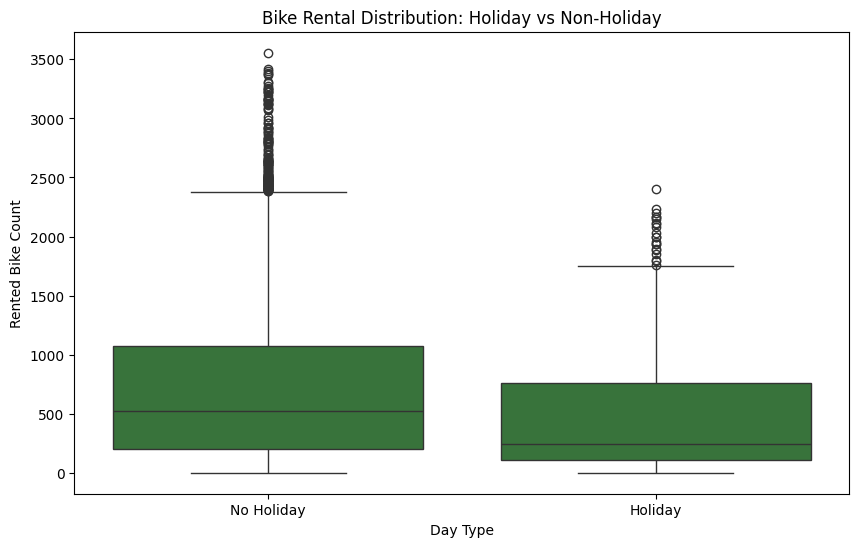

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Holiday', y='Rented Bike Count',color=green_aurora)
plt.title('Bike Rental Distribution: Holiday vs Non-Holiday')
plt.xlabel('Day Type')
plt.ylabel('Rented Bike Count')
plt.show()


* The above box chart compares the average bike rental demand on holidays vs non-holidays.
* Bike rentals are generally high on non-holidays compared to holidays.
* Features Used - Holiday, Rented Bike Count
* This indicates that bike usage is mainly driven by daily commuting, with people renting bike more on non-holidays compared to holidays.

### Correlation Heatmap

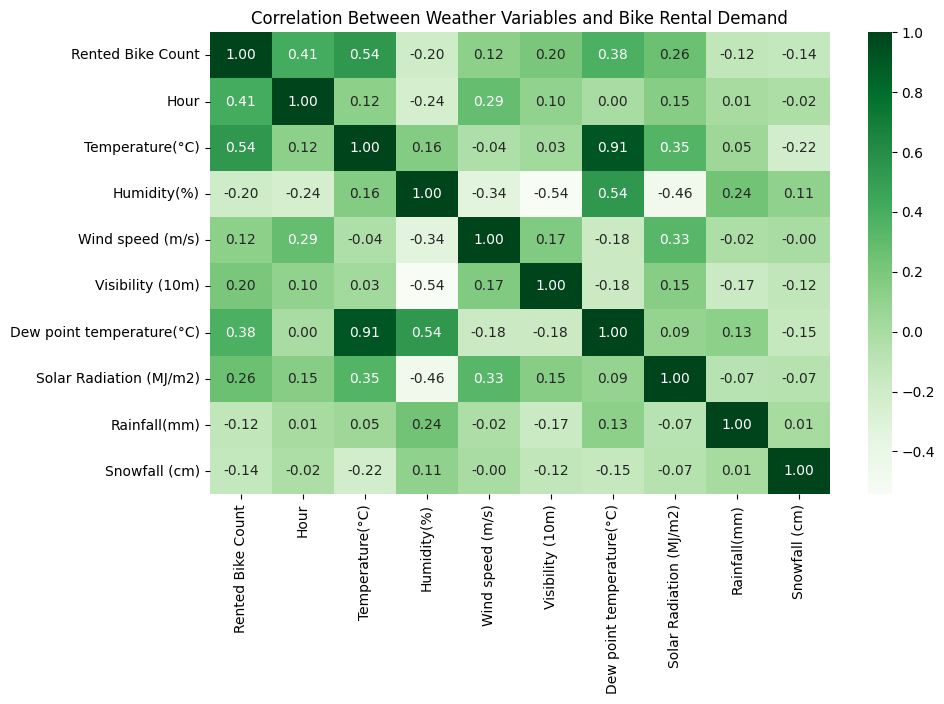

In [ ]:
plt.figure(figsize=(10,6))
corr = num_col.corr()

sns.heatmap(corr, annot=True, cmap='Greens', fmt=".2f")
plt.title("Correlation Between Weather Variables and Bike Rental Demand")
plt.show()


* The above heatmap shows the correlation between numerical variables and rented bike count.
* Temperature and hour show a strong positive relationship with bike rentals, while rainfall and snowfall show a negative relationship.
* Features Used – Numeric columns (num_col), Rented Bike Count.
* This indicates that weather conditions and time of the day significantly influence bike rental demand in Seoul.

### Hourly Bike Rentals Across Seasons

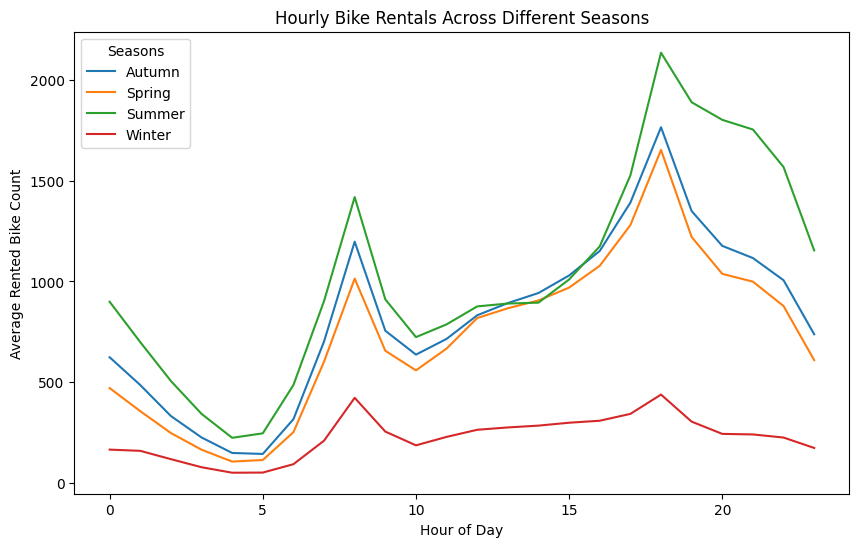

In [ ]:
hr_season = df.groupby(['Hour','Seasons'])['Rented Bike Count'].mean().round(2).reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=hr_season, x='Hour', y='Rented Bike Count', hue='Seasons')
plt.title("Hourly Bike Rentals Across Different Seasons")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rented Bike Count")
plt.show()


* The above line chart shows bike rental demand across different hours for each season.
* Peak rental hours are consistent in all seasons, but overall demand is much higher in summer and lower in winter.
* Features Used – Hour, Seasons, Rented Bike Count.
* This shows that both time of day and seasonal weather together affect bike usage patterns.

### Functional Day vs Rentals

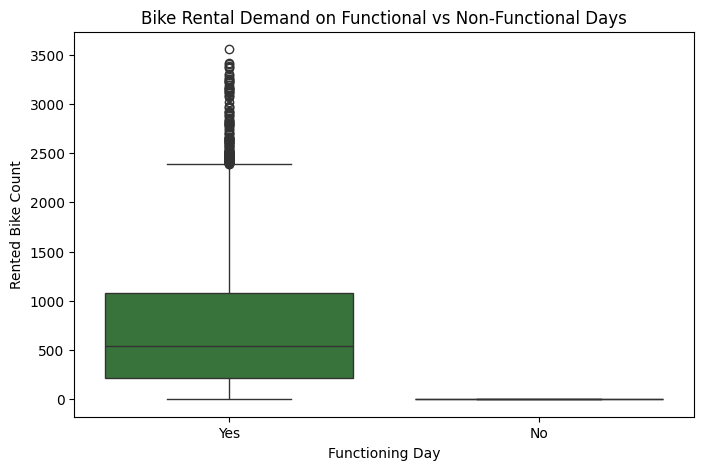

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Functioning Day', y='Rented Bike Count',color=green_aurora)
plt.title("Bike Rental Demand on Functional vs Non-Functional Days")
plt.xlabel("Functioning Day")
plt.ylabel("Rented Bike Count")
plt.show()


* The above box chart compares bike rental demand on functioning and non-functioning days.
* Bike rentals are almost zero on non-functioning days and significantly higher on functioning days.
* Features Used – Functional Day, Rented Bike Count.
* This indicates that system availability directly impacts rental demand, independent of user behavior.

### Snowfall vs Rentals

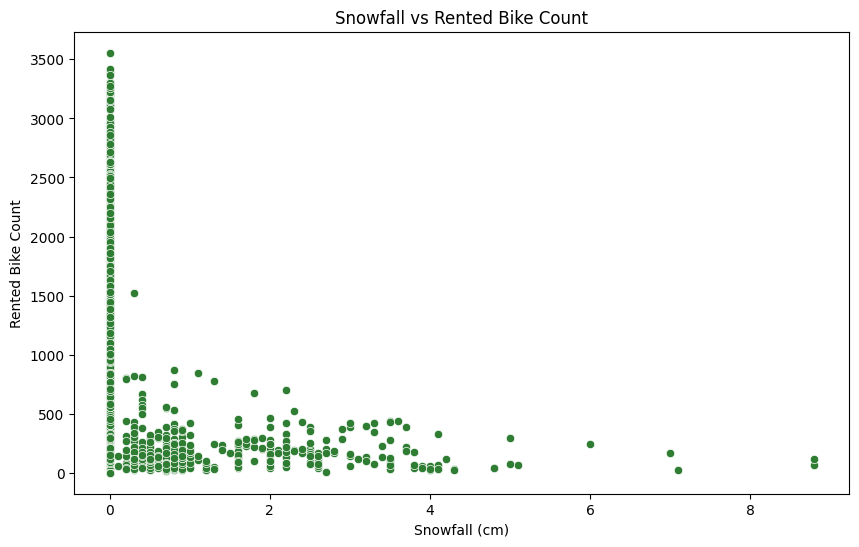

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Snowfall (cm)', y='Rented Bike Count',color=green_aurora)
plt.title("Snowfall vs Rented Bike Count")
plt.xlabel("Snowfall (cm)")
plt.ylabel("Rented Bike Count")
plt.show()


* The above scatter plot shows the relationship between snowfall and bike rental demand.
* Bike rentals decrease sharply as snowfall increases, with very low demand during heavy snow.
* Features Used – Snowfall(cm), Rented Bike Count.
* This indicates that snowfall strongly affects the bike usage and also explains low demand during winter conditions.

### Diagnostic - Key Insights

* Bike rental increases with higher temperatures and drastically reduces during rainfall and snowfall, showing that weather factors directly affects usage.
* Seasonal demand differences are mainly driven by weather conditions, with high usage in summer and low usage in winter.
* Rentals are significantly higher on functioning days and non-holidays, indicating that demand is mostly driven by daily commuting.
* Peak rental hours remain similar across seasons, but overall demand varies based on weather conditions.
* Overall, both the weather and system availability together explain most variations in bike rental demand in Seoul.

## Stage 4 – Documentation, Insights and Presentation

Show a dashboard aligning all the charts in powerbi by connecting python in PowerBI

Summarize findings in plain English (what do the patterns mean)

Highlight 3–5 key insights (trends, anomalies, correlations)

Provide recommendations for business or decision-making

Explain the FINAL STORY WITH THE DASHBOARD/report

Create a PDF pasting your DASHBOARD, explaining all the above mentioned concepts and submit it


In [ ]:
# your stage 4 pdf Link
https://drive.google.com/file/d/1WdJAfJ48gUYKBAZ_jbREpMJoMKUFe-pE/view?usp=sharing
'''
step1 --> Create a docs that should have all the above mentioned
step2 --> Save it as "Stage4_doc"
Step3 --> Download it as PDF
step4 --> Upload the pdf in your drive
step5 --> Right click on your pdf in drive
step6 --> click share and change access into anyone with the link (Viewer)
step7 --> click copy link and paste it here...
You are done.
'''

# Future Enhancement

* Use a larger and more recent dataset to capture updated usage patterns and improve insight accuracy.

* Automate data analysis and reporting using scripts or scheduled dashboards for faster updates.

* Add more advanced and interactive visualizations using Power BI or Tableau to improve decision-making.

* Extend the analysis to predictive modeling to forecast future bike rental demand based on weather and time factors.

# Conclusion

The analysis clearly show how bike rentals usage work in Seoul. Most people rent bike during morning and evening office hours and the usage increase when the weather is warm and dry.

Working days have much higher rental demand that holidays, proving that bike rentals are driven by regular usage. Additionally, seasonal patterns confirm that summer has the highest bike usage, while winter has the lowest due to weather conditions.

These insights enable service providers to optimize bike availability, reduce costs, and plan maintenance effectively.

Overall, this dashboard converts the data into clear and actionable insights that support better urban transportation planning.

